# Plan complet notebook : Livrable 2 – Traitement d’images

#  1. Introduction

Dans ce notebook, nous cherchons à améliorer la qualité d’images bruitées à l’aide d’un autoencodeur convolutif. Le but est de réaliser un prétraitement de données pour les rendre plus exploitables par des algorithmes de Machine Learning. Nous utiliserons un modèle d’autoencodeur entraîné à éliminer le bruit tout en conservant les détails visuels essentiels.

In [15]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from perlin_noise import PerlinNoise
import matplotlib.pyplot as plt
import numpy as np
import os

# Machine learning / deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
print("TensorFlow:", tf.__version__)
print("Keras (lié à TF):", tf.keras.__version__)


TensorFlow: 2.20.0
Keras (lié à TF): 3.11.3


# 2. Chargement et exploration du dataset

Indique quel dataset on utilises et impémentation de certain hyper paramétre essentiele a l'entrainement

In [59]:
data_dir = 'C:/Users/REAL/PycharmProjects/Bloc_IA_FISE5/Datasett/train2014'

#data_dir = "Dataset_livrable2"
#data_dir = r"C:\Users\REAL\PycharmProjects\Bloc_IA_FISE5\Projet\TRUE_2_Livrable\Dataset_image_livrable2"

IMG_SIZE = (128, 128)

BATCH_SIZE = 32
EPOCHS = 10

SEED = 42

scale = 0.1

latent_dim = 10



# 2.1 Création du model

Dans cette partie nous assoctions notre data sett au hyperparamétre

il n'y a pas de label car ce n'est pas un modéle de classification

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode=None
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode=None
)

Found 82783 files.
Using 66227 files for training.
Found 82783 files.
Using 16556 files for validation.


 # 2.2 Data pre-processing

Uniformiser la taille des images
Les réseaux de neurones exigent que toutes les images aient la même dimension d’entrée (ex. 128×128×3).
→ Si nous avons des tailles différentes, le modèle ne pourra pas les traiter en batch.

Normaliser les valeurs de pixels
Les valeurs brutes des pixels vont de 0 à 255.
On les normalise entre 0 et 1 pour :

faciliter la convergence de l’entraînement,

stabiliser les calculs,

éviter des gradients trop grands.

Mélanger et batcher les données
Pour un apprentissage stable, il faut créer des lots (batches) d’images mélangées.
Cela permet d’optimiser plus efficacement les poids du réseau.

Ajouter du bruit aux images propres

In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x: normalization_layer(x))
val_dataset = val_dataset.map(lambda x: normalization_layer(x))

In [6]:
# Optimisation (préchargement)
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Nous affichons quelque image de notre datasett

In [7]:
def display_images(dataset, n=10, title="Exemples d’images"):
    plt.figure(figsize=(10, 4))
    for images in dataset.take(1):  # Prend un batch d’images
        for i in range(n):
            ax = plt.subplot(2, 5, i + 1)
            plt.imshow(images[i].numpy())
            plt.axis("off")

    plt.suptitle(title)
    plt.show()

def display_noisy_images(dataset, n=5):
    for noisy_images, clean_images in dataset.take(1):
        plt.figure(figsize=(12, 4))
        for i in range(n):
            # Image propre
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(clean_images[i].numpy())
            plt.title("Propre")
            plt.axis("off")

            # Image bruitée
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(noisy_images[i].numpy())
            plt.title("Bruitée")
            plt.axis("off")
        plt.show()


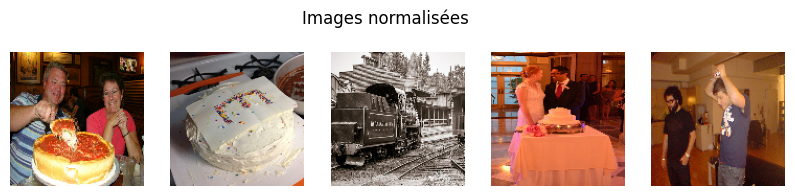

In [8]:
display_images(train_dataset, n=5, title="Images normalisées")



# 3. Ajout de bruit (simulation du bruit)

In [9]:
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * tf.random.normal(shape=tf.shape(images))
    noisy = tf.clip_by_value(noisy, 0., 1.)
    return noisy

train_noisy = train_dataset.map(lambda x: (add_noise(x), x))
val_noisy = val_dataset.map(lambda x: (add_noise(x), x))



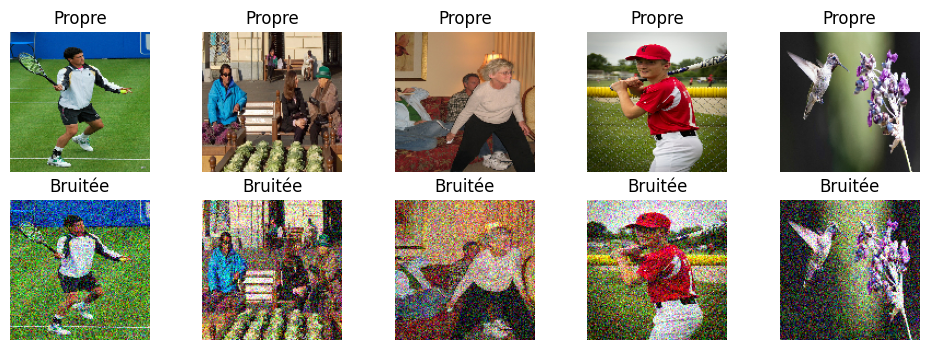

In [10]:
display_noisy_images(train_noisy, n=5)


### Résumé du pipeline de prétraitement








# 4. Construction de l’Autoencodeur Convolutionnel
Architecture type :

Un autoencodeur convolutionnel se compose de :

Encodeur : réduit la dimension via des convolutions + pooling.

Décodeur : reconstruit l’image via des convolutions transposées.

Exemple simple :

## 4.1 Autoencodeur Convolutiof

compresse l’image bruitée pour en extraire les caractéristiques essentielles (patterns, formes, textures).

les couche présente dans ce modéle :

#### Conv2D(n, (3,3))

Applique n filtres de convolution 3x3 sur l’image.
Chaque filtre détecte un motif local (contours, textures, couleurs…).
L’activation ReLU garde uniquement les valeurs positives → introduit de la non-linéarité.

#### MaxPooling2D
Réduit la taille des images de moitié (ex : 128×128 → 64×64).
Garde l’essentiel tout en éliminant les détails fins (comme du bruit !).

#### Flatten() transforme les cartes 2D en un vecteur 1D.

#### Dense(latent_dim) réduit à un espace latent

In [48]:
# The encoding process
input_img = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# --- ENCODEUR ---

input_img = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.Flatten()(x)

z = layers.Dense(latent_dim, name="latent_vector")(x)

encoder = keras.Model(input_img, z, name="encoder")
encoder.summary()
# Note:
# padding is a hyper-arameter for either 'valid' or 'same'.
# "valid" means "no padding".
# "same" results in padding the input such that the output has the same length as the original input.

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,978 (5.36 MB)

 Trainable params: 1,403,978 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Decoder

C’est l’inverse : on reconstruit une image à partir du vecteur latent.

#### Dense + Reshape

On déplie le vecteur latent pour retrouver une forme 2D exploitable.
On part d’un petit cube de 16×16×16.

#### UpSampling2D
is just a simple scaling up of the image by using nearest neighbour or bilinear upsampling, so nothing smart. Advantage is it's cheap.

#### Conv2DTranspose
 is a convolution operation whose kernel is learnt (just like normal conv2d operation) while training your model. Using Conv2DTranspose will also upsample its input but the key difference is the model should learn what is the best upsampling for the job.

Ces couches ajoutent de plus en plus de détails visuels.
Plus de filtres → plus de richesse visuelle
Chaque étape reconstruit des textures et couleurs fines.

#### Activation

##### RELU

##### SIGMOID

valeurs normalisées entre 0 et 1 (pour une image propre).

In [53]:
# --- DÉCODEUR ---
latent_inputs = keras.Input(shape=(latent_dim,))

# On re-projette dans une forme 2D

x = layers.Dense(32 * 32 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((32, 32, 64))(x)

x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same', strides=2)(x)  # 64x64
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x)   # 128x128
decoded_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(latent_inputs, decoded_output, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 65536)          │       720,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 64, 64, 128)    │        73,856 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,275 (3.32 MB)

 Trainable params: 870,275 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# -- TEST--
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

latency = encoder(inputs)
output = decoder(latency)

ae = keras.Model(inputs, output, name="ae")

ae.compile(optimizer="adamW", loss="mse")

## AE

un autoencodeur de débruitage, deux éléments clés pilotent l’apprentissage :
    *1.l’optimiseur (optimizer)
    *2.la fonction de coût (loss function)

Le but du débruitage est de transformer une image bruitée (entrée) en une image propre (sortie).
Le modèle apprend cesi via une fonction de cout, c'est pout cela qu'on a essyer plusieur modéle avec plusieur fonction de cout pour améliorais le résultat finale

La fonction de coût mesure à quel point la sortie du modèle est différente de l’image originale.

In [54]:
# Declare the model
autoencoder_input = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)

autoencoder = keras.Model(autoencoder_input, decoded_img, name="autoencoder")
autoencoder.compile(optimizer='adamW',
                    loss='mae',
                    metrics=[tf.keras.metrics.MeanSquaredError()]  # ou une métrique custom PSNR/SSIM
)
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 10)             │     1,403,978 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       870,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,274,253 (8.68 MB)

 Trainable params: 2,274,253 (8.68 MB)

 Non-trainable params: 0 (0.00 B)

### Callback

In [36]:
class DenoisingProgressCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, output_dir='progress_images', num_images=5):
        super().__init__()
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)

        # On récupère un petit batch du dataset (noisy, clean)
        sample_noisy, sample_clean = next(iter(dataset))
        self.sample_noisy = sample_noisy[:num_images].numpy()
        self.sample_clean = sample_clean[:num_images].numpy()

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.sample_noisy)
        num_images = len(self.sample_noisy)

        plt.figure(figsize=(12, 4 * num_images))
        for i in range(num_images):
            plt.subplot(num_images, 3, 3 * i + 1)
            plt.imshow(self.sample_noisy[i])
            plt.title("Noisy")
            plt.axis("off")

            plt.subplot(num_images, 3, 3 * i + 2)
            plt.imshow(predictions[i])
            plt.title("Denoised")
            plt.axis("off")

            plt.subplot(num_images, 3, 3 * i + 3)
            plt.imshow(self.sample_clean[i])
            plt.title("Clean")
            plt.axis("off")

        save_path = os.path.join(self.output_dir, f"epoch_{epoch+1:03d}.png")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()
        print(f"Images sauvegardées : {save_path}")


### Fonction de cout



In [28]:
from tensorflow.python.ops.image_ops_impl import ssim


def combined_loss(y_true, y_pred):
    # --- Mean Squared Error ---
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # --- SSIM (Structural Similarity) ---
    # SSIM renvoie une valeur entre -1 et 1 (1 = parfait)
    ssim_loss = 1 - tf.reduce_mean(ssim(y_true, y_pred, max_val=1.0))

    # --- Combinaison des deux ---
    return 0.5 * mse + 0.5 * ssim_loss

# 5. Entraînement du modèle

In [18]:
%load_ext tensorboard

In [19]:
for batch in train_dataset.take(1):
    print(len(batch))
    print(type(batch))
    break


32
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [32]:
for element in train_dataset.take(1):
    print(element)


tf.Tensor(
[[[[0.03284314 0.05147059 0.0509804 ]
   [0.37647063 0.24558824 0.2514706 ]
   [0.29901963 0.11764707 0.08284314]
   ...
   [0.17254902 0.20392159 0.11666667]
   [0.2029412  0.22549021 0.15      ]
   [0.26029414 0.27450982 0.1872549 ]]

  [[0.19068629 0.1514706  0.18627451]
   [0.04803922 0.02843137 0.05539216]
   [0.03333334 0.06862745 0.15049021]
   ...
   [0.1642157  0.18186276 0.1132353 ]
   [0.16127452 0.19656864 0.12205883]
   [0.23235296 0.24411766 0.16960785]]

  [[0.11127452 0.09558824 0.09950981]
   [0.0877451  0.08480392 0.09607844]
   [0.08088236 0.13480394 0.27205884]
   ...
   [0.15784314 0.19264707 0.11029413]
   [0.15833335 0.19362746 0.11813726]
   [0.22843139 0.2392157  0.16519609]]

  ...

  [[0.21617648 0.21274512 0.10294119]
   [0.18529412 0.19705884 0.08431373]
   [0.2029412  0.19509806 0.09705883]
   ...
   [0.1259804  0.13039216 0.11862746]
   [0.2764706  0.2897059  0.30245098]
   [0.21764708 0.21960786 0.2259804 ]]

  [[0.21078433 0.1897059  0.086764

In [57]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('AE_6H_0.0041_MSE.keras', save_best_only=True, monitor='val_loss'),
    DenoisingProgressCallback(train_noisy, output_dir='progress_images', num_images=5)
]


In [60]:
history = autoencoder.fit(
    train_noisy,
    validation_data=val_noisy,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/10
   6/2070 ━━━━━━━━━━━━━━━━━━━━ 21:53 637ms/step - loss: 0.1340 - mean_squared_error: 0.0358

KeyboardInterrupt: 

# 5.1 AUTRE MODEL HYPERPARAMETRE

on change la loss fonction

In [31]:
autoencoder.compile(
    optimizer='adam',
    loss='mae',
    metrics=[tf.keras.metrics.MeanSquaredError()]  # ou une métrique custom PSNR/SSIM
)

# callback pour sauvegarder en .keras
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_autoencoder_mase.keras', save_best_only=True, monitor='val_loss')
]

history = autoencoder.fit(train_noisy,
                          validation_data=val_noisy,
                          epochs=EPOCHS,
                          callbacks=callbacks)


Epoch 1/10


ValueError: Dimensions must be equal, but are 128 and 16 for '{{node compile_loss/mae/sub}} = Sub[T=DT_FLOAT](data_1, autoencoder_1/decoder_1/conv2d_transpose_3_1/Sigmoid)' with input shapes: [?,128,128,3], [?,16,16,3].

# 6. Évaluation & Visualisation des résultats

Afficher les résultats :

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


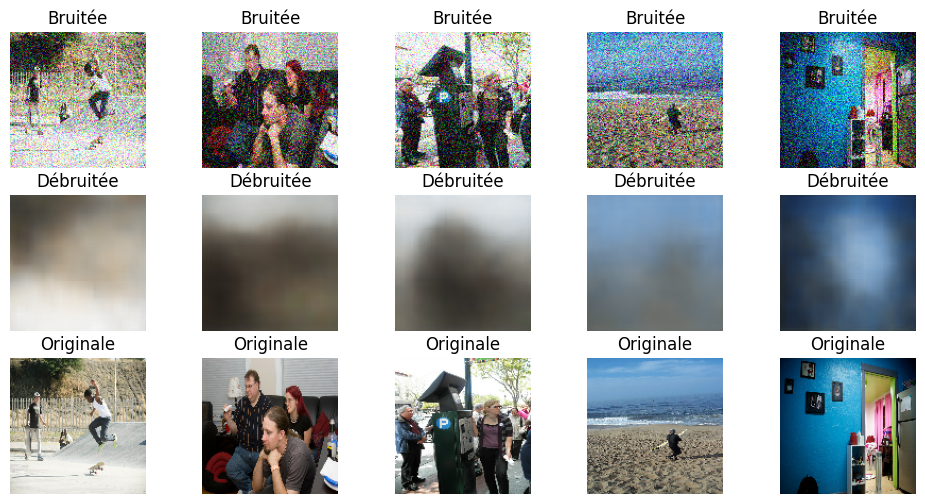

In [74]:
for noisy_imgs, clean_imgs in val_noisy.take(1):
    denoised_imgs = autoencoder.predict(noisy_imgs)

    plt.figure(figsize=(12, 6))
    for i in range(5):
        ax = plt.subplot(3,5,i+1)
        plt.imshow(noisy_imgs[i])
        plt.title("Bruitée")
        plt.axis("off")

        ax = plt.subplot(3,5,i+6)
        plt.imshow(denoised_imgs[i])
        plt.title("Débruitée")
        plt.axis("off")

        ax = plt.subplot(3,5,i+11)
        plt.imshow(clean_imgs[i])
        plt.title("Originale")
        plt.axis("off")
    plt.show()

In [73]:
def evaluate_batch(clean, pred):
    # clean, pred : tensors shape (B,H,W,C) values in [0,1]
    psnr = tf.image.psnr(clean, pred, max_val=1.0)
    ssim = tf.image.ssim(clean, pred, max_val=1.0)
    return tf.reduce_mean(psnr).numpy(), tf.reduce_mean(ssim).numpy()

# Exemple d'utilisation sur validation
for noisy, clean in val_noisy.take(1):
    pred = autoencoder.predict(noisy)
    print("PSNR:", evaluate_batch(clean, pred)[0])
    print("SSIM:", evaluate_batch(clean, pred)[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
PSNR: 15.252577
SSIM: 0.26140898


# 7. Étude de cas (interprétation)

# 8. Conclusion

Résume les performances du débruitage

Mentionne les axes d’amélioration possibles :

architecture plus profonde,

plus d’époques,

dropout,

autres types de bruit, etc.

